#### Frame the problem
* the objective of the project is to create a model that predicts which passengers survived the Titanic shipwreck. 
* the model will be Supervised, Offline.
* the performance will be measured by Confusion Matrix,roc,auc,accuracy.


# Importing lib

In [1]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd
from scipy.stats import norm
from scipy import stats

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn_processing
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,make_scorer,f1_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest,f_regression

# sklearn_algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

# Load Data

In [2]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')

#  Data Exploration

In [3]:
data = train.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


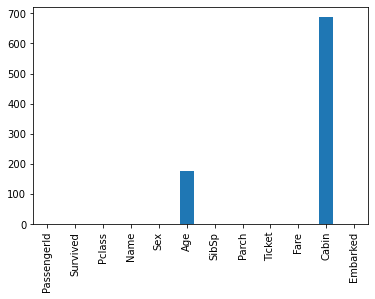

In [7]:
# Visualizing how many null values.
data_null = data.isna().sum()
data_null.plot.bar()

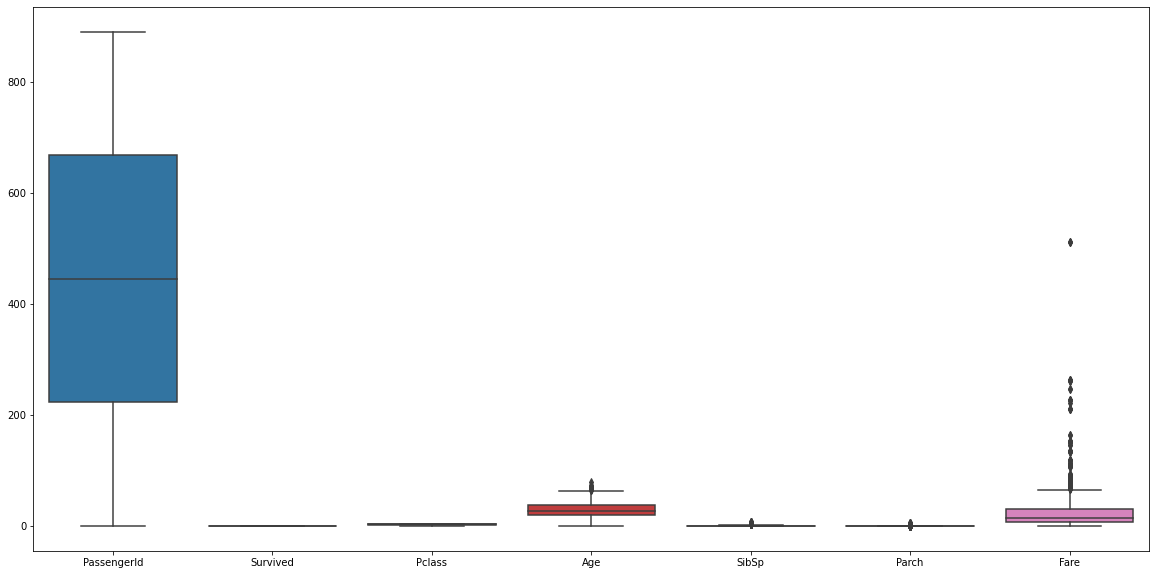

In [8]:
# Noisiness & Outliers check
data_num = data.select_dtypes('number')
plt.figure(figsize=(20,10))
sns.boxplot(data=data_num)

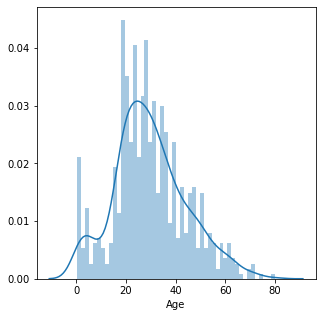

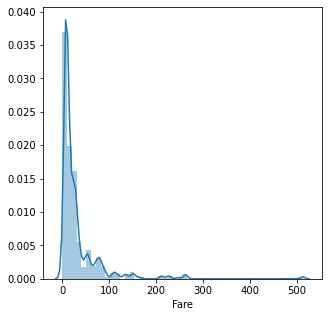

In [9]:
# data distribution:
for col in ['Age','Fare']:
    plt.figure(figsize=(5,5))
    sns.distplot(data_num[col],bins=50,kde = True)

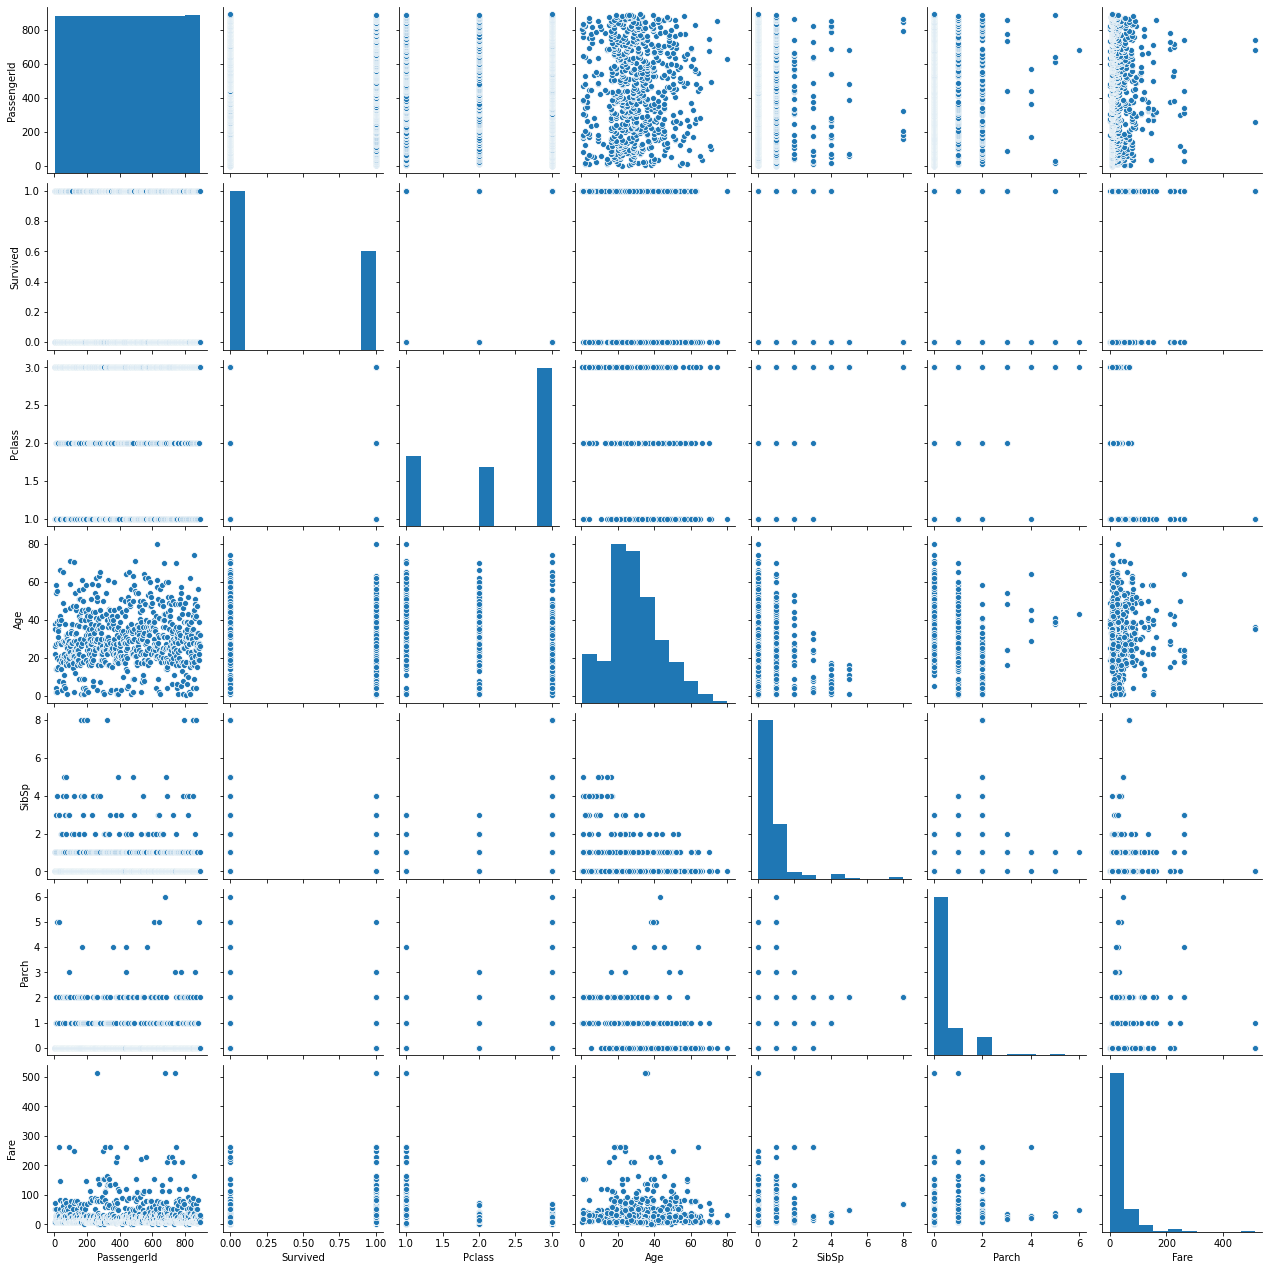

In [10]:
sns.pairplot(data_num)

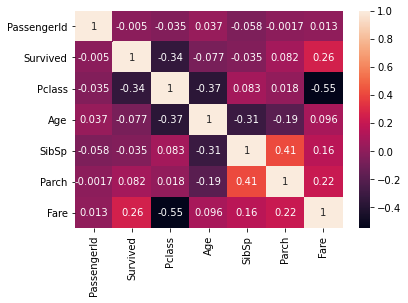

In [11]:
# Feature correlation:
corr = data_num.corr()
sns.heatmap(corr,annot=True)

## Exploration Summary:
* **5 features are object type** ... Name is TEXT....Sex is Ordinal categorical .... Ticket is text ..... Cabin & Embarked are nominal categorical.
* **For NAN values**             ... Age has 177 over 891 .... Cabin has 687 over 891.... Embarked has 2 over 891.
* **for outliers**               ... it may be exist in Age and Highly  exist in Fare.
* **for distribution type**      ... most of the features are right skewed.

# Data Preparation

### data cleaning

##### fixing outliers in Age & Fare:


In [12]:

# Gaussian boundaries for Age only since it is normally distributed
upper_boundary = data['Age'].mean()+3*data['Age'].std()
lower_boundary = data['Age'].mean()-3*data['Age'].std()
print('For Age: the upper boundary is '+str(upper_boundary))
print('For Age: the lower boundary is '+str(lower_boundary))

print('-------------------------------------')
# IQR to calculate boundaries:
for col in ['Age','Fare']:
    IQR = data[col].quantile(0.75)-data[col].quantile(0.25)
    lower_bridge = data[col].quantile(0.25)-(IQR*1.5)
    upper_bridge = data[col].quantile(0.75)+(IQR*1.5)
    print('for ',str(col),' the lower bridge is ' + str(lower_bridge))
    print('for ',str(col),' the upper bridge is ' + str(upper_bridge))
    
print('-------------------------------------')
# Extreme outliers
for col in ['Age','Fare']:
    IQR = data[col].quantile(0.75)-data[col].quantile(0.25)
    lower_bridge = data[col].quantile(0.25)-(IQR*3)
    upper_bridge = data[col].quantile(0.75)+(IQR*3)
    print('for ',str(col),' the lower bridge is ' + str(lower_bridge))
    print('for ',str(col),' the upper bridge is ' + str(upper_bridge))
    

For Age: the upper boundary is 73.27860964406095
For Age: the lower boundary is -13.88037434994331
-------------------------------------
for  Age  the lower bridge is -6.6875
for  Age  the upper bridge is 64.8125
for  Fare  the lower bridge is -26.724
for  Fare  the upper bridge is 65.6344
-------------------------------------
for  Age  the lower bridge is -33.5
for  Age  the upper bridge is 91.625
for  Fare  the lower bridge is -61.358399999999996
for  Fare  the upper bridge is 100.2688


In [13]:
# Age will be fixed by Gaussian boundaries but Fare will be fixed by Extreme
data.Age[data.Age>=73]=73
data.Fare[data.Fare>=100]=100

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [14]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.687913,0.523008,0.381594,27.027169
std,257.353842,0.486592,0.836071,14.490589,1.102743,0.806057,27.296632
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,73.000000,8.000000,6.000000,100.000000


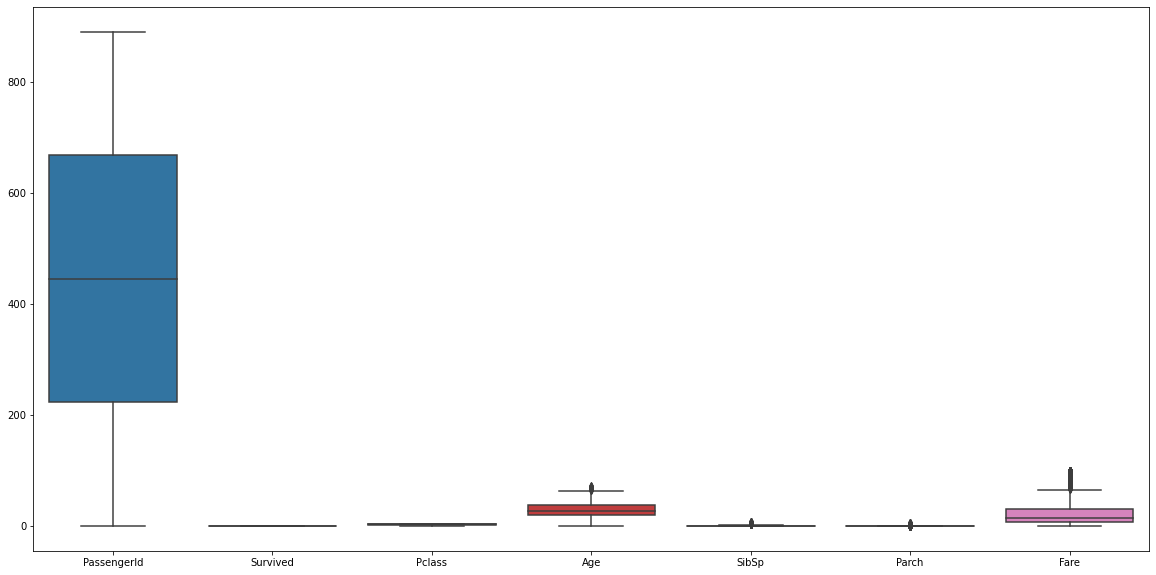

In [15]:
plt.figure(figsize=(20,10))
sns.boxplot(data=data.select_dtypes('number'))

##### Impute Missing Values

In [16]:
data['Cabin'].value_counts()


B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
E101           3
              ..
D47            1
D6             1
A19            1
C87            1
B4             1
Name: Cabin, Length: 147, dtype: int64

In [17]:

data['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [18]:
s_imputer = SimpleImputer(strategy='most_frequent')
I_imputer = IterativeImputer()
def missing_values(data):
    data['Cabin'].fillna('none',inplace= True)
    data['Age'] = I_imputer.fit_transform(data[['Age']])
    data[[col for col in data.columns if col not in ['Age','Cabin']]] = s_imputer.fit_transform(data[[col for col in data.columns if col not in ['Age','Cabin']]])
    return
missing_values(data)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Feature Engineering

In [19]:
passenger_Id = data['PassengerId']
y_train = data['Survived']

In [20]:
data.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,148,3
top,"Stanley, Mr. Edward Roland",male,1601,none,S
freq,1,577,7,687,646


In [21]:
def feature_extraction(data):
    data.drop(['Ticket','Cabin'],axis=1,inplace =True)
    name = pd.Series(data['Name']).str.split(',',expand=True)
    name_ = pd.Series(name[1]).str.split('.',expand=True)
    data.Name = name_[0]
    return
feature_extraction(data)
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Mr,male,22.000000,1,0,7.2500,S
1,2,1,1,Mrs,female,38.000000,1,0,71.2833,C
2,3,1,3,Miss,female,26.000000,0,0,7.9250,S
3,4,1,1,Mrs,female,35.000000,1,0,53.1000,S
4,5,0,3,Mr,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,Rev,male,27.000000,0,0,13.0000,S
887,888,1,1,Miss,female,19.000000,0,0,30.0000,S
888,889,0,3,Miss,female,29.687913,1,2,23.4500,S
889,890,1,1,Mr,male,26.000000,0,0,30.0000,C


In [22]:
data[['Name', 'Survived']].groupby(['Name'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Name,Survived
16,the Countess,1.000000
9,Mlle,1.000000
15,Sir,1.000000
13,Ms,1.000000
5,Lady,1.000000
10,Mme,1.000000
12,Mrs,0.792000
8,Miss,0.697802
7,Master,0.575000
1,Col,0.500000


In [23]:
data.drop(['Survived','PassengerId'],axis=1, inplace = True)

In [24]:
data.Name.value_counts()

 Mr              517
 Miss            182
 Mrs             125
 Master           40
 Dr                7
 Rev               6
 Col               2
 Mlle              2
 Major             2
 Lady              1
 Sir               1
 the Countess      1
 Ms                1
 Jonkheer          1
 Capt              1
 Mme               1
 Don               1
Name: Name, dtype: int64

In [25]:
# Replacing Rare names by grouping them as one category
def replace_rare(data):
    data['Name'].replace([' Lady', ' the Countess',' Capt', ' Col',
                                         ' Don', ' Major', ' Sir', ' Jonkheer', ' Dona'], ' Rare',inplace=True)

    data['Name'].replace(' Mlle', ' Miss',inplace=True)
    data['Name'].replace(' Ms', ' Miss',inplace=True)
    data['Name'].replace(' Mme', ' Mrs',inplace=True)
    print(data.Name.value_counts())
    return
replace_rare(data)

 Mr        517
 Miss      185
 Mrs       126
 Master     40
 Rare       10
 Dr          7
 Rev         6
Name: Name, dtype: int64


In [26]:
data

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,Mr,male,22.000000,1,0,7.2500,S
1,1,Mrs,female,38.000000,1,0,71.2833,C
2,3,Miss,female,26.000000,0,0,7.9250,S
3,1,Mrs,female,35.000000,1,0,53.1000,S
4,3,Mr,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,2,Rev,male,27.000000,0,0,13.0000,S
887,1,Miss,female,19.000000,0,0,30.0000,S
888,3,Miss,female,29.687913,1,2,23.4500,S
889,1,Mr,male,26.000000,0,0,30.0000,C


In [27]:
# categorical encoding
ohe = OneHotEncoder(handle_unknown='ignore')
col_transformer = make_column_transformer((OrdinalEncoder(categories= [['male','female'],['S','C','Q']]),
                                        ['Sex','Embarked']),remainder = 'passthrough')
def categorical_encoding(data_):
    global data

    cat_name = ohe.fit_transform(data_['Name'].to_numpy().reshape(-1, 1)).toarray()
    ohe_df = pd.DataFrame(cat_name, columns=ohe.get_feature_names())
    data_ = pd.concat([data_, ohe_df], axis=1).drop(['Name'], axis=1)

    data__ = col_transformer.fit_transform(data_)
    data = pd.DataFrame(data__, columns=['Sex','Embarked']+[col for col in data_.columns if col not in ['Sex','Embarked']]) 
    
    return data

######## OneHotEncoding for All

#col_transformer = make_column_transformer((OneHotEncoder(handle_unknown='ignore'),
 #                                          ['Sex','Name','Embarked']),remainder = 'passthrough')
#def categorical_encoding(data_):
 #   global data
  #  data__ = col_transformer.fit_transform(data_)
   # data = pd.DataFrame(data__) 
    #data.columns = [0 ,1, 2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 'Age' ,14 ,15, 'Fare']
    #return data
    
categorical_encoding(data)

,Sex,Embarked,Pclass,Age,SibSp,Parch,Fare,x0_ Dr,x0_ Master,x0_ Miss,x0_ Mr,x0_ Mrs,x0_ Rare,x0_ Rev
0,0.0,0.0,3.0,22.000000,1.0,0.0,7.2500,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,1.0,1.0,38.000000,1.0,0.0,71.2833,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,3.0,26.000000,0.0,0.0,7.9250,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,35.000000,1.0,0.0,53.1000,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,3.0,35.000000,0.0,0.0,8.0500,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,0.0,2.0,27.000000,0.0,0.0,13.0000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
887,1.0,0.0,1.0,19.000000,0.0,0.0,30.0000,0.0,0.0,1.0,0.0,0.0,0.0,0.0
888,1.0,0.0,3.0,29.687913,1.0,2.0,23.4500,0.0,0.0,1.0,0.0,0.0,0.0,0.0
889,0.0,1.0,1.0,26.000000,0.0,0.0,30.0000,0.0,0.0,0.0,1.0,0.0,0.0,0.0


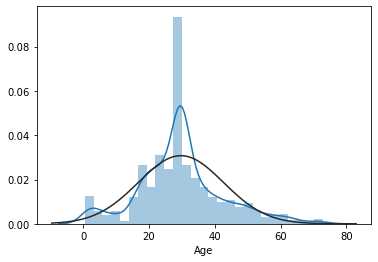

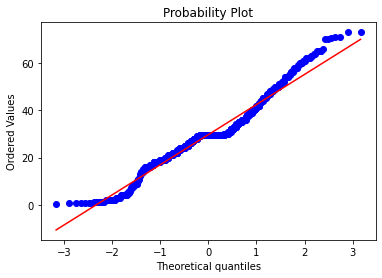

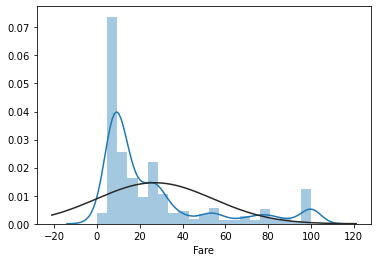

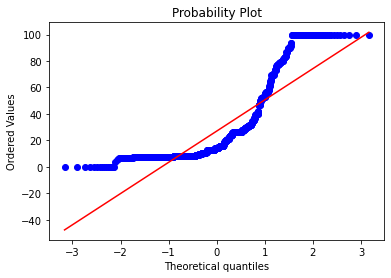

In [28]:
# Transform Features (Normality)
cols = ['Age' ,'Fare']
for col in cols:
    fig = plt.figure()

    sns.distplot(data[col], fit=norm);
    fig = plt.figure()
    stats.probplot(data[col], plot=plt)

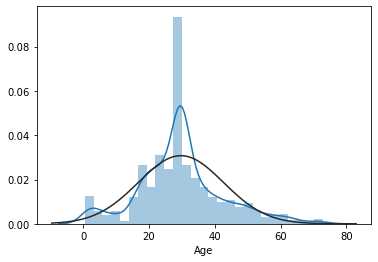

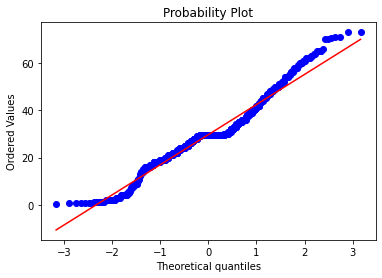

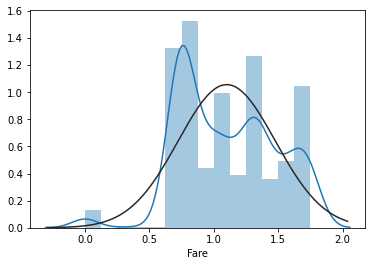

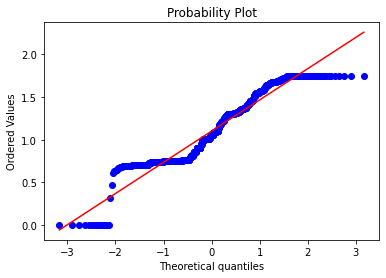

In [29]:
def transform_data(data):
    data['Fare'], parameters = stats.boxcox(data['Fare'].replace(0,1))
    data['Fare'], parameters = stats.boxcox(data['Fare'].replace(0,1))
    return
transform_data(data)
for col in cols:
    fig = plt.figure()

    sns.distplot(data[col], fit=norm);
    fig = plt.figure()
    stats.probplot(data[col], plot=plt)

### Feature Scaling

In [30]:
# Feature Scaling for Age attribute
std_scaler = StandardScaler()
data.Age = std_scaler.fit_transform(data.Age.to_numpy().reshape(-1,1))


### Making Processing PipeLine for test and new data

In [31]:
def processing_pipeline(test):
    
    def missing_values_(test):
        test['PassengerId'] , test['Survived'] = passengerid , y_train
        test['Cabin'].fillna('none',inplace= True)
        test['Age'] = I_imputer.transform(test[['Age']])
        test[[col for col in test.columns if col not in ['Age','Cabin']]] = s_imputer.transform(test[[col for col in test.columns if col not in ['Age','Cabin']]])
        test.drop(['PassengerId','Survived'],axis = 1, inplace=True)
        return

    missing_values_(test)
    
    feature_extraction(test)

    replace_rare(test)

    def categorical_encoding(test_):
        global test

        cat_name = ohe.transform(test_['Name'].to_numpy().reshape(-1, 1)).toarray()
        ohe_df = pd.DataFrame(cat_name, columns=ohe.get_feature_names())
        test_ = pd.concat([test_, ohe_df], axis=1).drop(['Name'], axis=1)

        data__ = col_transformer.transform(test_)
        test = pd.DataFrame(data__, columns=['Sex','Embarked']+[col for col in test_.columns if col not in ['Sex','Embarked']]) 
    
        return 

    categorical_encoding(test)
    
    def transform_data():
        global test
        test['Fare'], parameters = stats.boxcox(test['Fare'].replace(0,1))
        test['Fare'], parameters = stats.boxcox(test['Fare'].replace(0,1))
        return
    
    transform_data()
    
    def std():
        global test
        test.Age = std_scaler.transform(test.Age.to_numpy().reshape(-1,1))
        return
    std()
    return test

## Preparation Summary:
* **missing_values** Function
* **Feature_extraction** Function
* **replace_rare** Function
* **categorical_encoding** Function
* **transform_data** Function
* **Feature Scaling** Code
* **Processing_pipeline** Function

# Training models

### 1. Logistic Regression Model

In [32]:
logistic_model = LogisticRegression()
logistic_model.fit(data,y_train)
y_pred_logistic = logistic_model.predict(data)

Model Evaluation

In [33]:
def scoring(y_train,y_pred):
    print('The classification Report:\n ', classification_report(y_train,y_pred))
    print('--------------------------------------------')
    print('The Confusion Matrix:\n ', confusion_matrix(y_train,y_pred))
    return
scoring(y_train,y_pred_logistic)

The classification Report:
                precision    recall  f1-score   support

           0       0.85      0.87      0.86       549
           1       0.79      0.75      0.77       342

    accuracy                           0.83       891
   macro avg       0.82      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891

--------------------------------------------
The Confusion Matrix:
  [[479  70]
 [ 84 258]]



#### Cross validation Score

In [34]:
def score(y_train, y_pred):
    print(classification_report(y_train, y_pred)) 
    print('----------------------------------------------------------')
    print(confusion_matrix(y_train, y_pred))
    print('----------------------------------------------------------')

    return f1_score(y_train,y_pred)
    

In [35]:
logistic_score = cross_val_score(logistic_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       110
           1       0.75      0.78      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

----------------------------------------------------------
[[92 18]
 [15 54]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.75      0.74        68

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178

----------------------------------------------------------
[[92 18]
 [17 51]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0     

### 2. SVC & LinearSVC Model

In [36]:
# SVC
svc_model = SVC()
svc_model.fit(data,y_train)
y_pred_scv = svc_model.predict(data)

# LinearSVC
linearsvc_model = LinearSVC()
linearsvc_model.fit(data,y_train)
y_pred_linearscv = linearsvc_model.predict(data)

/opt/conda/lib/python3.7/site-packages/sklearn/svm/_base.py:977: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


Model Evaluation

In [37]:
# SVC
scoring(y_train,y_pred_scv)

# LinearSVC
scoring(y_train,y_pred_linearscv)

The classification Report:
                precision    recall  f1-score   support

           0       0.84      0.90      0.87       549
           1       0.82      0.73      0.77       342

    accuracy                           0.84       891
   macro avg       0.83      0.82      0.82       891
weighted avg       0.84      0.84      0.83       891

--------------------------------------------
The Confusion Matrix:
  [[494  55]
 [ 91 251]]
The classification Report:
                precision    recall  f1-score   support

           0       0.85      0.89      0.87       549
           1       0.80      0.74      0.77       342

    accuracy                           0.83       891
   macro avg       0.83      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891

--------------------------------------------
The Confusion Matrix:
  [[487  62]
 [ 88 254]]


#### Cross validation Score

In [38]:
# SVC
svc_score = cross_val_score(svc_model,data,y_train,scoring= make_scorer(score), cv=5)
print('==========================================')
# LinearSVC
linearsvc_score = cross_val_score(linearsvc_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       110
           1       0.83      0.78      0.81        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

----------------------------------------------------------
[[99 11]
 [15 54]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.77      0.75      0.76        68

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178

----------------------------------------------------------
[[95 15]
 [17 51]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0     

/opt/conda/lib/python3.7/site-packages/sklearn/svm/_base.py:977: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/svm/_base.py:977: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


### 3.RandomForestClassifier Model

In [39]:
forest_model = RandomForestClassifier()
forest_model.fit(data,y_train)
y_pred_forest = forest_model.predict(data)

Model Evaluation

In [40]:
scoring(y_train,y_pred_forest)

The classification Report:
                precision    recall  f1-score   support

           0       0.99      0.99      0.99       549
           1       0.98      0.98      0.98       342

    accuracy                           0.98       891
   macro avg       0.98      0.98      0.98       891
weighted avg       0.98      0.98      0.98       891

--------------------------------------------
The Confusion Matrix:
  [[543   6]
 [  8 334]]


#### Cross validation Score

In [41]:
forest_score = cross_val_score(forest_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

----------------------------------------------------------
[[92 18]
 [18 51]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.69      0.72        68

    accuracy                           0.79       178
   macro avg       0.78      0.77      0.78       178
weighted avg       0.79      0.79      0.79       178

----------------------------------------------------------
[[94 16]
 [21 47]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0     

###  4.KNeighborsClassifier

In [42]:
kn_model = KNeighborsClassifier()
kn_model.fit(data,y_train)
y_pred_kn = kn_model.predict(data)

Model Evaluation

In [43]:
scoring(y_train,y_pred_kn)

The classification Report:
                precision    recall  f1-score   support

           0       0.87      0.91      0.89       549
           1       0.84      0.79      0.81       342

    accuracy                           0.86       891
   macro avg       0.86      0.85      0.85       891
weighted avg       0.86      0.86      0.86       891

--------------------------------------------
The Confusion Matrix:
  [[499  50]
 [ 73 269]]


#### Cross validation Score

In [44]:
kn_score = cross_val_score(kn_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

----------------------------------------------------------
[[95 15]
 [19 50]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       110
           1       0.71      0.71      0.71        68

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178

----------------------------------------------------------
[[90 20]
 [20 48]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0     

### 5.GaussianNB

In [45]:
naive_model = GaussianNB()
naive_model.fit(data,y_train)
y_pred_naive = naive_model.predict(data)

Model Evaluation

In [46]:
scoring(y_train,y_pred_naive)

The classification Report:
                precision    recall  f1-score   support

           0       0.96      0.04      0.08       549
           1       0.39      1.00      0.56       342

    accuracy                           0.41       891
   macro avg       0.68      0.52      0.32       891
weighted avg       0.74      0.41      0.27       891

--------------------------------------------
The Confusion Matrix:
  [[ 23 526]
 [  1 341]]


#### Cross validation Score

In [47]:
naive_score = cross_val_score(naive_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       1.00      0.05      0.10       110
           1       0.40      1.00      0.57        69

    accuracy                           0.42       179
   macro avg       0.70      0.53      0.34       179
weighted avg       0.77      0.42      0.28       179

----------------------------------------------------------
[[  6 104]
 [  0  69]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.07      0.13       110
           1       0.40      0.99      0.57        68

    accuracy                           0.42       178
   macro avg       0.64      0.53      0.35       178
weighted avg       0.70      0.42      0.30       178

----------------------------------------------------------
[[  8 102]
 [  1  67]]
----------------------------------------------------------
              precision    recall  f1-score   support

         

### 6.Perceptron

In [48]:
perceptron_model = Perceptron()
perceptron_model.fit(data,y_train)
y_pred_perceptron = perceptron_model.predict(data)

In [49]:
scoring(y_train,y_pred_perceptron)

The classification Report:
                precision    recall  f1-score   support

           0       0.90      0.59      0.71       549
           1       0.58      0.89      0.70       342

    accuracy                           0.71       891
   macro avg       0.74      0.74      0.71       891
weighted avg       0.77      0.71      0.71       891

--------------------------------------------
The Confusion Matrix:
  [[325 224]
 [ 38 304]]


#### Cross validation Score

In [50]:
perceptron_score = cross_val_score(perceptron_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       0.67      0.97      0.80       110
           1       0.85      0.25      0.38        69

    accuracy                           0.69       179
   macro avg       0.76      0.61      0.59       179
weighted avg       0.74      0.69      0.64       179

----------------------------------------------------------
[[107   3]
 [ 52  17]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.76      0.66      0.71        68

    accuracy                           0.79       178
   macro avg       0.78      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178

----------------------------------------------------------
[[96 14]
 [23 45]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0 

### 7.SGDClassifier

In [51]:
sgd_model = SGDClassifier()
sgd_model.fit(data,y_train)
y_pred_sgd = sgd_model.predict(data)

Model Evaluation

In [52]:
scoring(y_train,y_pred_sgd)

The classification Report:
                precision    recall  f1-score   support

           0       0.89      0.74      0.81       549
           1       0.67      0.86      0.75       342

    accuracy                           0.78       891
   macro avg       0.78      0.80      0.78       891
weighted avg       0.81      0.78      0.79       891

--------------------------------------------
The Confusion Matrix:
  [[404 145]
 [ 49 293]]


#### Cross validation Score

In [53]:
sgd_score = cross_val_score(sgd_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       0.86      0.69      0.77       110
           1       0.63      0.83      0.71        69

    accuracy                           0.74       179
   macro avg       0.75      0.76      0.74       179
weighted avg       0.77      0.74      0.75       179

----------------------------------------------------------
[[76 34]
 [12 57]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       110
           1       0.70      0.57      0.63        68

    accuracy                           0.74       178
   macro avg       0.73      0.71      0.72       178
weighted avg       0.74      0.74      0.74       178

----------------------------------------------------------
[[93 17]
 [29 39]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0     

### 8.DecisionTreeClassifier

In [54]:
tree_model = DecisionTreeClassifier()
tree_model.fit(data,y_train)
y_pred_tree = tree_model.predict(data)

Model Evaluation

In [55]:
scoring(y_train,y_pred_tree)

The classification Report:
                precision    recall  f1-score   support

           0       0.98      1.00      0.99       549
           1       0.99      0.96      0.98       342

    accuracy                           0.98       891
   macro avg       0.99      0.98      0.98       891
weighted avg       0.98      0.98      0.98       891

--------------------------------------------
The Confusion Matrix:
  [[547   2]
 [ 12 330]]


#### Cross validation Score

In [56]:
tree_score = cross_val_score(tree_model,data,y_train,scoring= make_scorer(score), cv=5)

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       110
           1       0.69      0.70      0.69        69

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179

----------------------------------------------------------
[[88 22]
 [21 48]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       110
           1       0.71      0.74      0.72        68

    accuracy                           0.79       178
   macro avg       0.77      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178

----------------------------------------------------------
[[90 20]
 [18 50]]
----------------------------------------------------------
              precision    recall  f1-score   support

           0     

### The most promising models are: 
1. LogisticRegression Model
2. SVC Model 
3. RandomForestClassifier Model
4. KNeighborsClassifier Model
5. DecisionTreeClassifier Model

# Fine-Tune the models

### 1. LogisticRegression Model

In [57]:
logistic_pipeline = Pipeline([('selector',SelectKBest(f_regression)), ('model',LogisticRegression(random_state = 42,max_iter=1000))])

logistic_grid= GridSearchCV( estimator = logistic_pipeline, param_grid = {'selector__k':[12,13,14] , 
        'model__C':[0.1,1,2],'model__solver':['liblinear'],'model__penalty':['l1','l2']}, n_jobs=-1, scoring = make_scorer(score), cv=5, verbose=3)

In [58]:
logistic_grid.fit(data,y_train)
print('the best parameters : ',logistic_grid.best_params_)
print('the best score = ', logistic_grid.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    2.1s


the best parameters :  {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'selector__k': 13}
the best score =  0.7582511293321124


[Parallel(n_jobs=-1)]: Done  90 out of  90 | elapsed:    2.8s finished


### 2. SVC Model

In [59]:
svc_pipeline = Pipeline([('selector',SelectKBest(f_regression)), ('model',SVC(random_state = 42))])

svc_grid= GridSearchCV( estimator = svc_pipeline, param_grid = {'selector__k':[12,13,14] , 
        'model__C':[1,0.5],'model__kernel':['sigmoid','linear','rbf','poly']}, n_jobs=-1, scoring = make_scorer(score), cv=5, verbose=3)

In [60]:
svc_grid.fit(data,y_train)
print('the best parameters : ',svc_grid.best_params_)
print('the best score = ', svc_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    1.0s


the best parameters :  {'model__C': 1, 'model__kernel': 'rbf', 'selector__k': 13}
the best score =  0.7674936574311381


[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:    1.8s finished


### 3. RandomForestClassifier Model

In [61]:
forest_pipeline = Pipeline([('selector',SelectKBest(f_regression)), ('model',RandomForestClassifier(random_state = 42))])

forest_grid= GridSearchCV( estimator = forest_pipeline, param_grid = {'selector__k':[11,12,13] , 
        'model__n_estimators':np.arange(40,81,20),'model__max_depth':[5,7,9],
        'model__min_samples_split':[5,7,10],'model__max_features':[8,9,10]}, n_jobs=-1, scoring = make_scorer(score), cv=7, verbose=3)

In [62]:
forest_grid.fit(data,y_train)
print('the best parameters : ',forest_grid.best_params_)
print('the best score = ', forest_grid.best_score_)

Fitting 7 folds for each of 243 candidates, totalling 1701 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 232 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done 552 tasks      | elapsed:   38.6s
[Parallel(n_jobs=-1)]: Done 1000 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1576 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 1694 out of 1701 | elapsed:  2.2min remaining:    0.5s


the best parameters :  {'model__max_depth': 7, 'model__max_features': 9, 'model__min_samples_split': 7, 'model__n_estimators': 60, 'selector__k': 12}
the best score =  0.7965653257467465


[Parallel(n_jobs=-1)]: Done 1701 out of 1701 | elapsed:  2.2min finished


### 4. KNeighborsClassifier Model

In [63]:
kn_pipeline = Pipeline([('selector',SelectKBest(f_regression)), ('model',KNeighborsClassifier())])

kn_grid= GridSearchCV( estimator = kn_pipeline, param_grid = {'selector__k':[12,13,14] , 
        'model__n_neighbors':np.arange(5,15,2)}, n_jobs=-1, scoring = make_scorer(score), cv=5, verbose=3)

In [64]:
kn_grid.fit(data,y_train)
print('the best parameters : ',kn_grid.best_params_)
print('the best score = ', kn_grid.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


the best parameters :  {'model__n_neighbors': 5, 'selector__k': 13}
the best score =  0.7549028712234417


[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  68 out of  75 | elapsed:    1.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed:    1.1s finished


### 5. DecisionTreeClassifier Model

In [65]:
tree_pipeline = Pipeline([('selector',SelectKBest(f_regression)), ('model',DecisionTreeClassifier())])

tree_grid= GridSearchCV( estimator = tree_pipeline, param_grid = {'selector__k':[10,11,12] , 
        'model__max_depth':[5,7,10],'model__min_samples_split':[5,7,10]}, n_jobs=-1, scoring = make_scorer(score), cv=8, verbose=3)

In [66]:
tree_grid.fit(data,y_train)
print('the best parameters : ',tree_grid.best_params_)
print('the best score = ', tree_grid.best_score_)

Fitting 8 folds for each of 27 candidates, totalling 216 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.6s


the best parameters :  {'model__max_depth': 7, 'model__min_samples_split': 7, 'selector__k': 11}
the best score =  0.7664331836289897


[Parallel(n_jobs=-1)]: Done 216 out of 216 | elapsed:    2.0s finished


### the most promising model 
**RandomForestClassifier**

# Final Model for Test set

### Working on Test data processing

In [67]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [68]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [69]:
passengerid = test['PassengerId']
test.drop('PassengerId',axis=1,inplace=True)

In [70]:
processing_pipeline(test)

 Mr        240
 Miss       79
 Mrs        72
 Master     21
 Rare        3
 Rev         2
 Dr          1
Name: Name, dtype: int64


,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,Mr,male,34.500000,0,0,7.8292,Q
1,3,Mrs,female,47.000000,1,0,7.0000,S
2,2,Mr,male,62.000000,0,0,9.6875,Q
3,3,Mr,male,27.000000,0,0,8.6625,S
4,3,Mrs,female,22.000000,1,1,12.2875,S
...,...,...,...,...,...,...,...,...
413,3,Mr,male,29.687913,0,0,8.0500,S
414,1,Rare,female,39.000000,0,0,108.9000,C
415,3,Mr,male,38.500000,0,0,7.2500,S
416,3,Mr,male,29.687913,0,0,8.0500,S


### Final Model 

In [71]:
model = forest_grid.best_estimator_

In [72]:
y_predicted = model.predict(test)

In [73]:
sub = pd.DataFrame()
sub['PassengerId'] = passengerid
sub['Survived'] = y_predicted
sub.to_csv('submission.csv',index=False)

### Ensemble Model
here will be predict based on voting from the 5 promising models

In [74]:
model_logisitc = logistic_grid.best_estimator_
model_svc      = svc_grid.best_estimator_
model_forest   = forest_grid.best_estimator_
model_kn       = kn_grid.best_estimator_
model_tree     = tree_grid.best_estimator_

In [75]:
y_predicted_logistic = model_logisitc.predict(test)
y_predicted_svc      = model_svc.predict(test)
y_predicted_forest   = model_forest.predict(test)
y_predicted_kn       = model_kn.predict(test)
y_predicted_tree     = model_tree.predict(test)

In [76]:
y_pred = stats.mode([y_predicted_logistic,y_predicted_svc,y_predicted_forest,y_predicted_kn,y_predicted_tree])

In [77]:
y_pred[0].T.shape

(418, 1)

In [78]:
sub_ensemble = pd.DataFrame()
sub_ensemble['PassengerId'] = passengerid
sub_ensemble['Survived'] = y_pred[0].T
sub_ensemble.to_csv('submission_ensemble.csv',index=False)